In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "studentmath"
namex = "Student-mat "
d = 30

###threshold
graphsx = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/studentmath_thresh_graphsummary.npy")
randomgraphsinfo


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Student-math (30),4.0,206,9,5,4,0.092233,0.063107,0.029126,2.111111,0.005063,0.004430,0.000633,10,5,190,1,0
1,Student-math (30),4.5,206,16,7,9,0.213592,0.111650,0.101942,2.750000,0.012368,0.006431,0.005937,14,13,174,0,1
2,Student-math (30),5.0,206,24,12,12,0.582524,0.368932,0.213592,5.000000,0.044684,0.028946,0.015738,25,19,145,0,2
3,Student-math (30),5.5,206,32,15,17,1.713592,0.966019,0.747573,11.031250,0.201349,0.116471,0.084878,24,34,97,0,3
4,Student-math (30),6.0,206,38,17,21,3.631068,2.038835,1.592233,19.684211,0.681773,0.404200,0.277573,21,27,61,0,4
5,Student-math (30),6.5,206,39,17,22,7.092233,3.902913,3.189320,37.461538,2.086657,1.221596,0.865060,8,22,33,0,5
6,Student-math (30),7.0,206,39,17,22,11.810680,6.233010,5.577670,62.384615,4.921344,2.769486,2.151857,8,23,9,0,6
7,Student-math (30),7.5,206,39,17,22,17.553398,8.956311,8.597087,92.717949,9.736879,5.188187,4.548693,2,12,3,0,7
8,Student-math (30),8.0,206,39,17,22,23.296117,11.572816,11.723301,123.051282,15.820649,8.202084,7.618565,0,8,1,0,8
9,Student-math (30),8.5,206,39,17,22,28.291262,13.674757,14.616505,149.435897,22.128439,11.164480,10.963959,1,3,0,0,9


## Compute and evaluate results for the targeted intervention model

In [4]:
summary_dfx = scripts.analytics.compute_itm_results(datasgraphs = graphsx,
                                                      thresh=True,
                                                      dsetname = name,
                                                      dsetdim = d)

summary_dfx.to_csv("./im_results/"+name+"_boost_results_thresh.csv", index=False)
summary_dfx.head(10)

,K,B,Sg,Sg_lbls,F(Sg),Sgb,Sgb_lbls,F(Sgb)b4B,F(Sgb),Boostedgb,...,Boostedbg,usedBbudgetbg,r,n,m,greedyTime,greedyBoostTime,boostGreedyTime,dataset,graphid
0,1,4,{0},{0: 1},11.0,{0},{0: 1},11.0,15.0,"[0, 1, 2, 3]",...,"[0, 1, 2, 3]",4,4.0,206,9,0.006237,0.006244,0.006315,studentmath (30),0
1,1,3,{0},{0: 1},11.0,{0},{0: 1},11.0,14.0,"[0, 1, 2]",...,"[0, 1, 2]",3,4.0,206,9,0.005854,0.006205,0.011595,studentmath (30),0
2,1,2,{0},{0: 1},11.0,{0},{0: 1},11.0,13.0,"[0, 1]",...,"[0, 1]",2,4.0,206,9,0.008616,0.005902,0.008913,studentmath (30),0
3,1,1,{0},{0: 1},11.0,{0},{0: 1},11.0,12.0,[0],...,[0],1,4.0,206,9,0.007381,0.005703,0.008994,studentmath (30),0
4,1,0,{0},{0: 1},11.0,{0},{0: 1},11.0,11.0,[],...,[],0,4.0,206,9,0.011583,0.005295,0.006370,studentmath (30),0
5,2,4,{0},{0: 1},11.0,{0},{0: 1},11.0,15.0,"[0, 1, 2, 3]",...,"[0, 1, 2, 3]",4,4.0,206,9,0.013934,0.017455,0.010642,studentmath (30),0
6,2,3,{0},{0: 1},11.0,{0},{0: 1},11.0,14.0,"[0, 1, 2]",...,"[0, 1, 2]",3,4.0,206,9,0.016683,0.015294,0.009762,studentmath (30),0
7,2,2,{0},{0: 1},11.0,{0},{0: 1},11.0,13.0,"[0, 1]",...,"[0, 1]",2,4.0,206,9,0.014146,0.011588,0.017443,studentmath (30),0
8,2,1,{0},{0: 1},11.0,{0},{0: 1},11.0,12.0,[0],...,[0],1,4.0,206,9,0.010955,0.014986,0.014466,studentmath (30),0
9,2,0,{0},{0: 1},11.0,{0},{0: 1},11.0,11.0,[],...,[],0,4.0,206,9,0.015814,0.011205,0.010848,studentmath (30),0


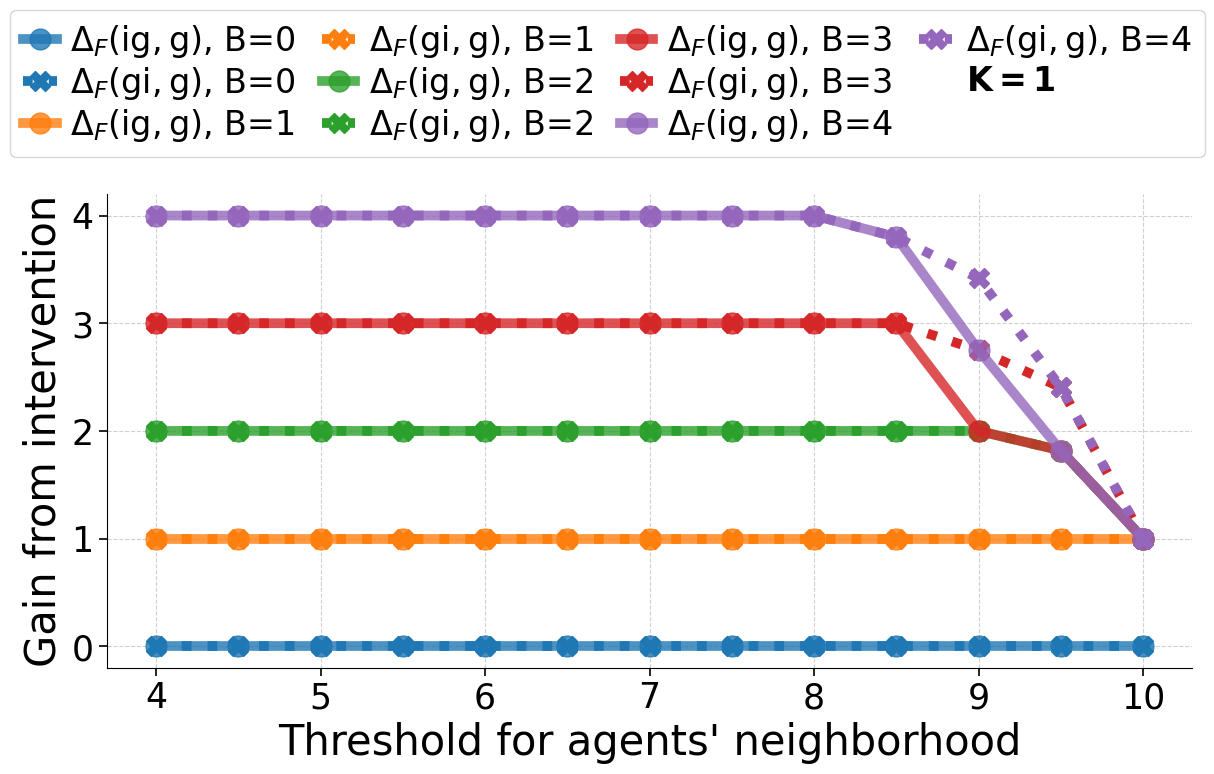

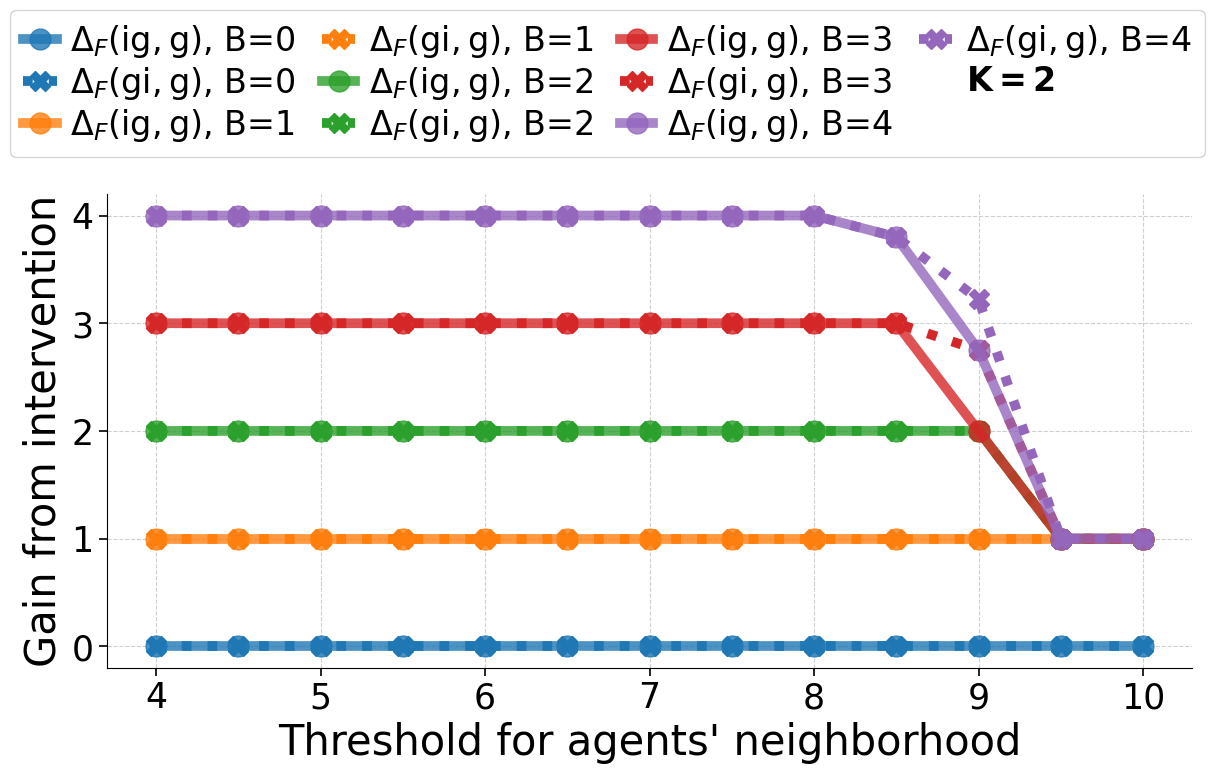

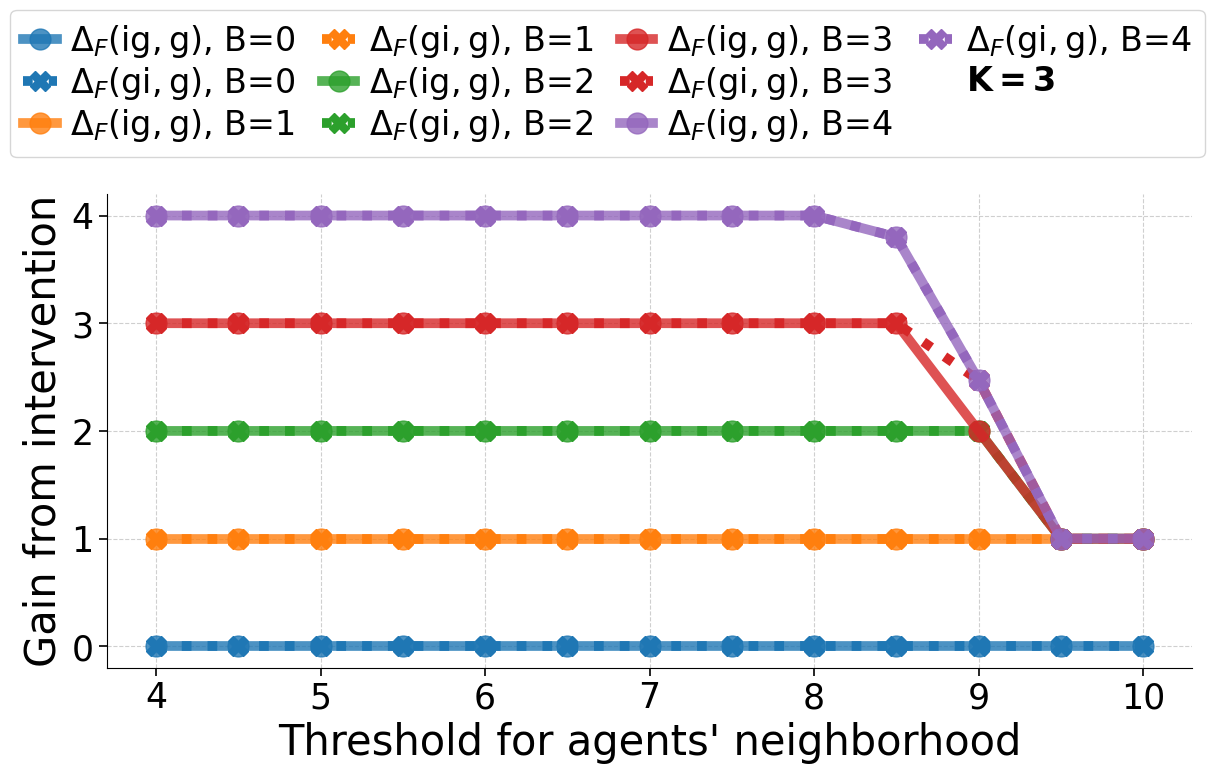

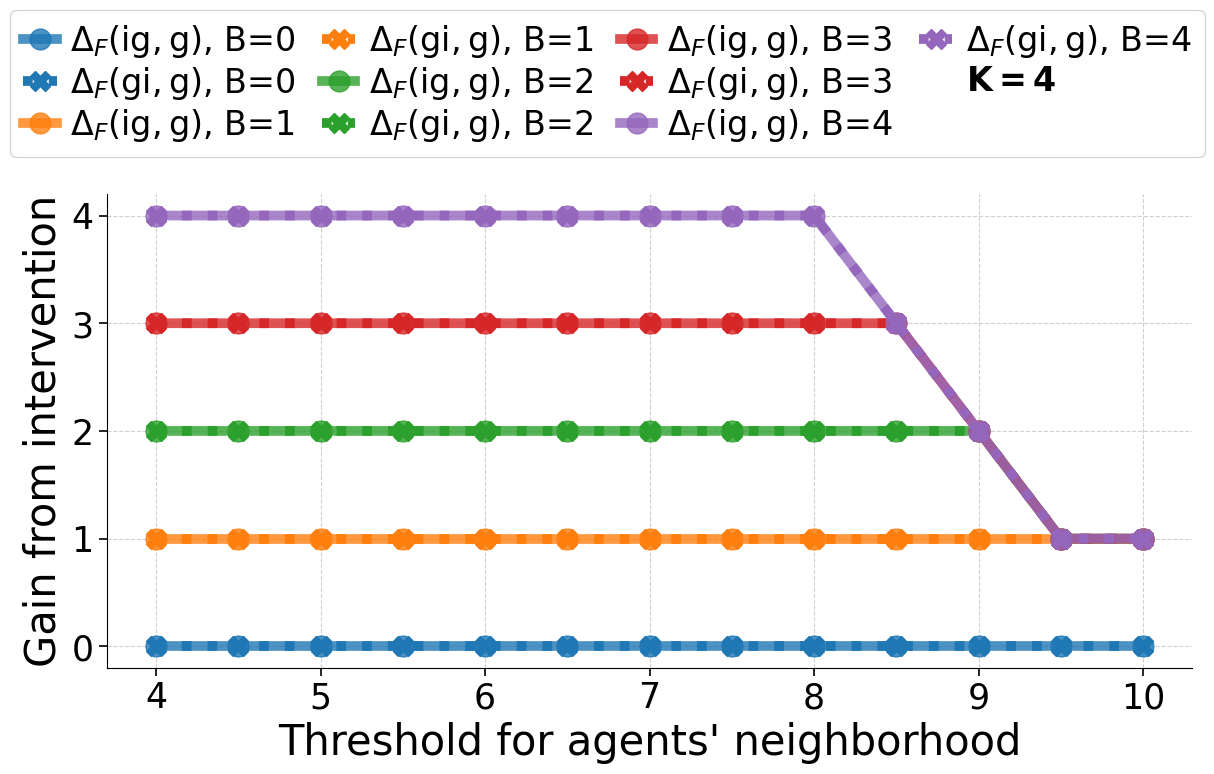

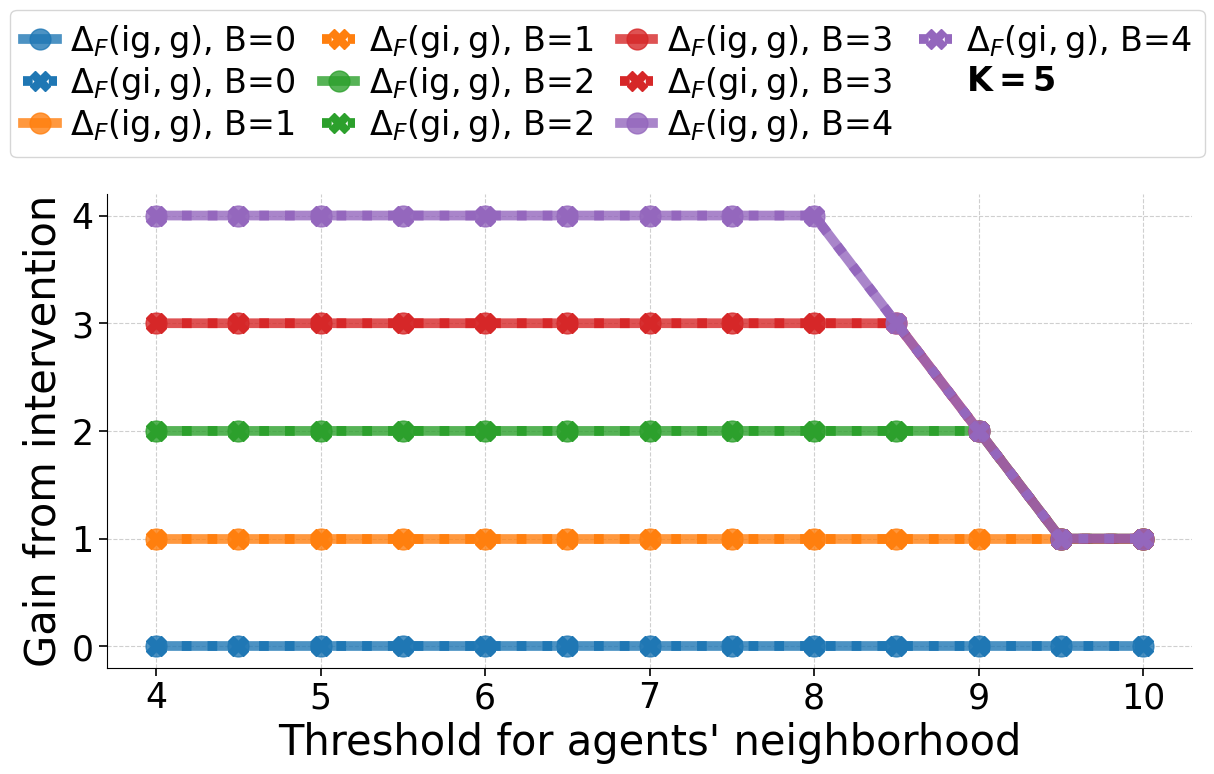

In [5]:
scripts.analytics.plot_intm_results(resdf = summary_dfx,
                                      thresh = True, 
                                      save_as = "./im_results/figures/"+name+"_imb4aftersm_results_thresh")